# Poisson GLM in PyTorch

We fit a Poisson GLM to the read counts of one gene, first with `statsmodels`, then with PyTorch, and check
that both give the same estimates, Wald tests and likelihood ratio test (LRT). Our RNA kinetics models are not
GLMs, so for them we have to do all of this by hand in PyTorch; here we learn how on a model where we can check
the answer.

## 1. Data

One gene, 12 samples, two binary interventions, 3 replicates of each combination.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

design_matrix = np.array([
    [0, 0],
    [0, 0],
    [0, 0],
    [0, 1],
    [0, 1],
    [0, 1],
    [1, 0],
    [1, 0],
    [1, 0],
    [1, 1],
    [1, 1], 
    [1, 1],
], dtype=float)
# Simulated from the model in section 2 with intercept log(50) (i.e. 50 reads without any intervention)
# and LFCs 0.7 and -0.3.
counts = np.array([56, 59, 56, 29, 35, 40, 99, 102, 112, 81, 82, 74], dtype=float)

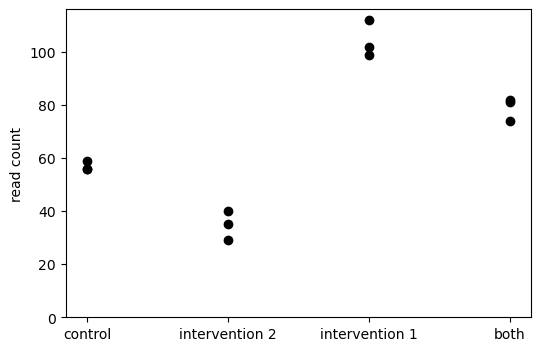

In [2]:
group_labels = ['control', 'intervention 2', 'intervention 1', 'both']

fig, ax = plt.subplots(figsize=(6, 4))
for position, label in enumerate(group_labels):
    rows = slice(3 * position, 3 * position + 3)
    ax.scatter(np.full(3, position), counts[rows], color='black')

ax.set_xticks(range(len(group_labels)))
ax.set_xticklabels(group_labels)
ax.set_ylabel('read count')
ax.set_ylim(bottom=0)
plt.show()

## 2. Model

We model the counts as

$$
y_i \sim \mathrm{Poisson}(\mu_i), \qquad \mu_i = \exp(\beta_0 + x_{i1} \beta_1 + x_{i2} \beta_2),
$$

where the intercept $\beta_0$ is the log of the expected count with no intervention, and $\beta_1, \beta_2$
are the log fold changes (LFCs, natural log) caused by the two interventions. The Poisson distribution with
mean $\mu$ gives the probability of observing $y$ reads as

$$
P(y \mid \mu) = \frac{\mu^y e^{-\mu}}{y!}, \qquad y = 0, 1, 2, \dots
$$

Its mean and variance are both equal to $\mu$.

Strictly, the reads of a gene are binomial: each of the $n$ reads in the library comes from this gene with some
small probability $p$, so

$$
P(y \mid n, p) = \binom{n}{y} p^y (1 - p)^{n - y}, \qquad y = 0, 1, \dots, n,
$$

with mean $np$ and variance $np(1 - p)$. For large $n$ and small $p$, $\mathrm{Binomial}(n, p)$ is well approximated by
$\mathrm{Poisson}(\mu = np)$ ([proof](https://mathcenter.oxford.emory.edu/site/math117/connectingPoissonAndBinomial/));
a common rule of thumb is $n \geq 20$ and $p \leq 0.05$. In RNA-seq, $n$ is in the millions and, with roughly
10,000 expressed genes, an average gene has $p \approx 10^{-4}$, so the approximation is excellent. Poisson is easier to
work with: a single parameter $\mu$, and no binomial coefficients of $n$.

For a single two-group comparison, a simple test would do (e.g. a t-test on log counts). GLMs pay off when we
need to account for several explanatory variables at once, as here.

## 3. The model in PyTorch

A PyTorch model is a subclass of `nn.Module`. Its trainable parameters are declared as `nn.Parameter` in the
constructor, and `forward` computes the model prediction from the data, here the expected counts $\mu_i$. We
start all parameters at 0.

We use 64-bit floats throughout; with the default 32-bit floats the results agree with `statsmodels` only to a
few decimal places.

In [3]:
import torch
from torch import nn

torch.set_default_dtype(torch.float64)


class PoissonGLM(nn.Module):

    def __init__(self, num_features: int):
        super().__init__()
        self.intercept = nn.Parameter(torch.zeros(()))
        self.lfc = nn.Parameter(torch.zeros(num_features))

    def forward(self, design_matrix: torch.Tensor) -> torch.Tensor:
        return torch.exp(self.intercept + design_matrix @ self.lfc)

In [4]:
design_matrix_torch = torch.tensor(design_matrix)
counts_torch = torch.tensor(counts)

model = PoissonGLM(num_features=design_matrix.shape[1])
for name, param in model.named_parameters():
    print(name, param)

intercept Parameter containing:
tensor(0., requires_grad=True)
lfc Parameter containing:
tensor([0., 0.], requires_grad=True)


Models are callable: `model(x)` runs `forward(x)` (always call the model, not `forward` directly). Since all
parameters are 0, the prediction is $\exp(0) = 1$ read for every sample, which is not a very interesting
prediction yet.

In [5]:
prediction = model(design_matrix_torch)
print(prediction)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       grad_fn=<ExpBackward0>)


## 4. Loss

We fit the model by maximum likelihood, i.e. by minimizing the negative log-likelihood

$$
\mathcal{L}(\beta) = -\sum_i \log P(y_i \mid \mu_i) = \sum_i \left( \mu_i - y_i \log \mu_i + \log y_i! \right).
$$

PyTorch has this built in as `nn.PoissonNLLLoss`. We set `log_input=False` because our model returns $\mu$, not
$\log \mu$, and `reduction='sum'` to sum over samples rather than average (this matters later for the standard
errors).

Caveat: by default it drops the constant $\log y_i!$, since it does not depend on the parameters and so does not
change the fit. The loss is then not the negative log-likelihood itself, only shifted by a constant.
`full=True` adds the term back, but only via Stirling's approximation, so even then it is not exact.

In [6]:
loss_fn = nn.PoissonNLLLoss(log_input=False, reduction='sum')

loss_fn(prediction, counts_torch)

tensor(12.0000, grad_fn=<SumBackward0>)

### Gradients with autograd

When we compute the loss, PyTorch records every operation on the way from the parameters to the loss
(`design_matrix @ lfc`, `+ intercept`, `exp`, the loss). `loss.backward()` walks back through these
operations and applies the chain rule, which gives the derivative of the loss with respect to every parameter.
The result is stored in the `.grad` attribute of each parameter.

For our model we can also derive the gradient by hand,
$\partial \mathcal{L} / \partial \beta_j = \sum_i (\mu_i - y_i)\, x_{ij}$, and check that autograd agrees. The
gradient is negative: the prediction (1 read) is far below the counts, so increasing the parameters lowers the
loss.

With the gradient we could do a gradient descent step by hand, e.g. `model.lfc -= learning_rate * model.lfc.grad`.
In practice we let an optimizer from `torch.optim` handle this for us.

In [7]:
loss = loss_fn(model(design_matrix_torch), counts_torch)
loss.backward()

print('loss:', loss)
print('intercept grad:', model.intercept.grad)
print('lfc grad:      ', model.lfc.grad)
residual = prediction.detach() - counts_torch  # detach: no need to track gradients of this check
print('by hand:       ', residual.sum(), residual @ design_matrix_torch)

loss: tensor(12.0000, grad_fn=<SumBackward0>)
intercept grad: tensor(-813.0000)
lfc grad:       tensor([-544.0000, -335.0000])
by hand:        tensor(-813.) tensor([-544., -335.])


When we don't need gradients, e.g. when we only want a prediction, we wrap the computation in
`with torch.no_grad():`. PyTorch then does not record the operations, which saves time and memory, and the
result has no `grad_fn`. The manual gradient descent step above would also need it, since PyTorch does not allow
modifying a parameter in place while it is recording.

In [8]:
with torch.no_grad():
    prediction = model(design_matrix_torch)
print(prediction)

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])


## 5. Training

Gradient descent repeatedly takes a small step against the gradient,
$\beta \leftarrow \beta - \eta \, \nabla \mathcal{L}(\beta)$, with learning rate $\eta$. In each iteration we
reset the gradients (`optimizer.zero_grad()`, otherwise `backward` adds to the old ones), compute the loss and
its gradient, and let the optimizer do the update (`optimizer.step()`). `torch.optim.SGD` on the full data set
is plain gradient descent. We stop once the loss improves by less than `tolerance`.

The learning rate is picked by hand: with `lr=1e-3` the loss decreases steadily, with `lr=1.5e-3` the steps
overshoot and the fit never converges, and smaller values just converge more slowly. Try it.

In [9]:
model = PoissonGLM(num_features=design_matrix.shape[1])
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
max_iter = 1000
tolerance = 1e-8

loss_history = []
for iteration in range(max_iter):
    optimizer.zero_grad()
    loss = loss_fn(model(design_matrix_torch), counts_torch)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if iteration > 0 and loss_history[-2] - loss_history[-1] < tolerance:
        break

print(f'Stopped after {iteration + 1} iterations, loss = {loss.item():.6f}')
print('intercept:', model.intercept.item())  # used to simulate the data: log(50) = 3.91
print('lfc:      ', model.lfc.tolist())  # used to simulate the data: 0.7, -0.3

Stopped after 106 iterations, loss = -2724.321693
intercept: 3.9848452275687825
lfc:       [0.69316213785797, -0.3501948705707674]


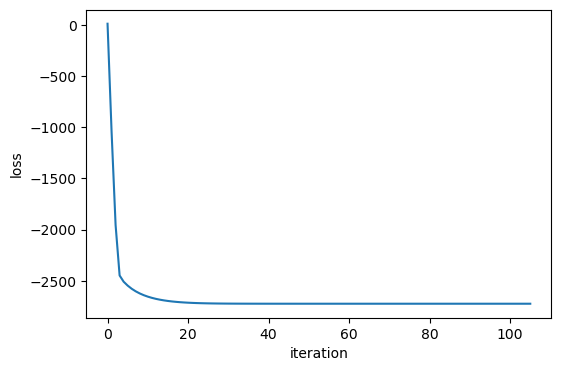

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_history)
ax.set_xlabel('iteration')
ax.set_ylabel('loss')
plt.show()

## 6. Wald test

For large samples, the log-likelihood near its maximum is approximately quadratic in the parameters, and the
maximum likelihood estimate $\hat\beta$ is approximately normally distributed,

$$
\hat\beta \sim \mathcal{N}\left(\beta, \, H^{-1}\right),
$$

where $H$ is the Hessian (matrix of second derivatives) of the loss at $\hat\beta$, also called the Fisher
information. Intuitively, a sharply curved loss pins the parameter down well (small variance), a flat one does
not.

The Wald test of $H_0: \beta_j = 0$ uses the standard error $\mathrm{SE}_j = \sqrt{(H^{-1})_{jj}}$:

$$
z_j = \frac{\hat\beta_j}{\mathrm{SE}_j} \sim \mathcal{N}(0, 1) \text{ under } H_0,
\qquad
p_j = 2 \left(1 - \Phi(|z_j|)\right).
$$

The constant term dropped from the loss has zero derivatives, so it does not affect $H$.

`torch.func.hessian` needs the loss as a function of the parameters. `functional_call` runs the model with the
parameters passed in as a dictionary, instead of the ones stored in the model. The result is a dictionary of
blocks, one per pair of parameters (`hessian_dict['intercept']['lfc']` etc.).

In [11]:
from torch.func import functional_call, hessian

model_parameters = dict(model.named_parameters())


def loss_by_params(params: dict[str, torch.Tensor]) -> torch.Tensor:
    prediction = functional_call(model, params, (design_matrix_torch,))
    return loss_fn(prediction, counts_torch)


hessian_dict = hessian(loss_by_params)(model_parameters)
hessian_dict

{'intercept': {'intercept': tensor(824.9983, grad_fn=<SqueezeBackward1>),
  'lfc': tensor([550.0016, 341.0008], grad_fn=<ViewBackward0>)},
 'lfc': {'intercept': tensor([550.0016, 341.0008], grad_fn=<SqueezeBackward1>),
  'lfc': tensor([[550.0016, 227.3350],
          [227.3350, 341.0008]], grad_fn=<ViewBackward0>)}}

We assemble the blocks into one matrix. Rows and columns follow the order of `model.named_parameters()`,
i.e. intercept, lfc_1, lfc_2.

In [12]:
def flatten_hessian_dict(hessian_dict: dict[str, dict[str, torch.Tensor]],
                         model_parameters: dict[str, torch.Tensor]) -> torch.Tensor:
    sizes = {name: param.numel() for name, param in model_parameters.items()}
    rows = [
        torch.cat([hessian_dict[name_1][name_2].reshape(sizes[name_1], sizes[name_2]) for name_2 in sizes], dim=1)
        for name_1 in sizes
    ]
    return torch.cat(rows, dim=0).detach()


hessian_matrix = flatten_hessian_dict(hessian_dict, model_parameters)
hessian_matrix

tensor([[824.9983, 550.0016, 341.0008],
        [550.0016, 550.0016, 227.3350],
        [341.0008, 227.3350, 341.0008]])

At a minimum of the loss the Hessian is positive semi-definite (the loss curves upwards in every direction).
For $H^{-1}$ to be a valid covariance matrix, we need $H$ to be positive definite, i.e. all eigenvalues
strictly positive. A zero eigenvalue would mean the loss is flat in some direction, so some combination of
parameters is not identifiable from the data. Here all eigenvalues are clearly positive.

(The largest eigenvalue is also what limited the learning rate in gradient descent: it has to be below
$2 / \lambda_{\max}$.)

In [13]:
torch.linalg.eigvalsh(hessian_matrix)

tensor([ 109.5747,  195.7488, 1410.6774])

In [14]:
from scipy import stats

cov_matrix = torch.linalg.inv(hessian_matrix)
estimates = torch.cat([param.detach().flatten() for param in model_parameters.values()])
standard_errors = torch.sqrt(torch.diag(cov_matrix))
z_scores = estimates / standard_errors
p_values = 2 * stats.norm.sf(np.abs(z_scores.numpy()))  # sf(x) = 1 - cdf(x), but accurate in the far tail

wald_results = pd.DataFrame({
    'estimate': estimates.numpy(),
    'SE': standard_errors.numpy(),
    'z_score': z_scores.numpy(),
    'p_value': p_values,
}, index=['intercept', 'lfc_1', 'lfc_2'])
wald_results

,estimate,SE,z_score,p_value
intercept,3.984845,0.067011,59.465964,0.000000e+00
lfc_1,0.693162,0.073855,9.385427,6.266208e-21
lfc_2,-0.350195,0.070701,-4.953162,7.301717e-07


Both LFCs are clearly significant. The test for the intercept ($\beta_0 = 0$, i.e. 1 read without
intervention) is not meaningful, we only report it for completeness.

## 7. Likelihood ratio test

The likelihood ratio test (LRT) compares the full model with a reduced model in which the tested parameter is
removed, here the LFC of intervention 1. The reduced model always fits at most as well as the full one; the
question is whether the full model fits significantly better. Under $H_0$ (the removed parameters are 0), the
statistic

$$
\Lambda = 2 \left( \mathcal{L}_{\text{reduced}} - \mathcal{L}_{\text{full}} \right)
= 2 \left( \log L_{\text{full}} - \log L_{\text{reduced}} \right)
$$

follows asymptotically a $\chi^2$ distribution with degrees of freedom equal to the number of removed parameters,
here 1 (Wilks' theorem). The constant dropped from the loss cancels in the difference.

We fit the reduced model the same way as the full one in section 5; to avoid copying the loop, here it is
wrapped in a function.

In [15]:
def train_model(model: nn.Module, design_matrix: torch.Tensor, counts: torch.Tensor,
                lr: float = 1e-3, max_iter: int = 1000, tolerance: float = 1e-8) -> list[float]:
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_history = []
    for iteration in range(max_iter):
        optimizer.zero_grad()
        loss = loss_fn(model(design_matrix), counts)
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())
        if iteration > 0 and loss_history[-2] - loss_history[-1] < tolerance:
            break
    return loss_history


# Drop intervention 1: the only remaining column is intervention 2.
reduced_design_matrix_torch = design_matrix_torch[:, [1]]

model_reduced = PoissonGLM(num_features=reduced_design_matrix_torch.shape[1])
loss_history_reduced = train_model(model_reduced, reduced_design_matrix_torch, counts_torch)

print(f'Stopped after {len(loss_history_reduced)} iterations')
print('intercept:', model_reduced.intercept.item())
print('lfc:      ', model_reduced.lfc.tolist())

Stopped after 72 iterations
intercept: 4.390319061302028
lfc:       [-0.35019008606575097]


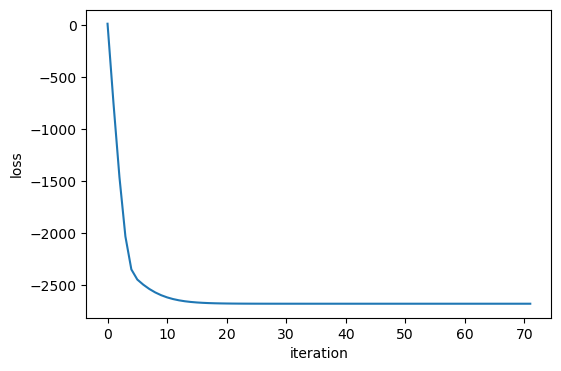

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_history_reduced)
ax.set_xlabel('iteration')
ax.set_ylabel('loss')
plt.show()

In [17]:
with torch.no_grad():
    loss_full = loss_fn(model(design_matrix_torch), counts_torch).item()
    loss_reduced = loss_fn(model_reduced(reduced_design_matrix_torch), counts_torch).item()

lrt_statistic = 2 * (loss_reduced - loss_full)
p_value_lrt = stats.chi2.sf(lrt_statistic, df=1)

print('loss full:     ', loss_full)
print('loss reduced:  ', loss_reduced)
print('LRT statistic: ', lrt_statistic)
print('p-value LRT:   ', p_value_lrt)
print('p-value Wald:  ', wald_results.loc['lfc_1', 'p_value'])

loss full:      -2724.321692701859
loss reduced:   -2677.5994575954737
LRT statistic:  93.44447021277028
p-value LRT:    4.177582007166122e-22
p-value Wald:   6.266207688367986e-21


The Wald test and the LRT are asymptotically equivalent, so their p-values are similar but not identical in a
finite sample. The Wald test needs only the full model; the LRT needs an extra fit, but is generally more
reliable in small samples.

## 8. Comparison with statsmodels

Finally, we fit the same models with `statsmodels`. Unlike our PyTorch model, `statsmodels` has no separate
intercept parameter, so we add a column of ones to the design matrix (`sm.add_constant`).

In [18]:
import statsmodels.api as sm

glm_full = sm.GLM(counts, sm.add_constant(design_matrix), family=sm.families.Poisson()).fit()
print(glm_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   12
Model:                            GLM   Df Residuals:                        9
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -38.611
Date:                Thu, 08 Oct 2026   Deviance:                       5.3490
Time:                        16:07:03   Pearson chi2:                     5.18
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9999
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9849      0.067     59.467      0.0

In [19]:
pd.DataFrame({
    'estimate_torch': wald_results['estimate'],
    'estimate_statsmodels': glm_full.params,
    'SE_torch': wald_results['SE'],
    'SE_statsmodels': glm_full.bse,
    'p_value_torch': wald_results['p_value'],
    'p_value_statsmodels': glm_full.pvalues,
})

,estimate_torch,estimate_statsmodels,SE_torch,SE_statsmodels,p_value_torch,p_value_statsmodels
intercept,3.984845,3.984860,0.067011,0.067010,0.000000e+00,0.000000e+00
lfc_1,0.693162,0.693147,0.073855,0.073855,6.266208e-21,6.276296e-21
lfc_2,-0.350195,-0.350202,0.070701,0.070701,7.301717e-07,7.297637e-07


In [20]:
glm_reduced = sm.GLM(counts, sm.add_constant(design_matrix[:, [1]]), family=sm.families.Poisson()).fit()

lrt_statistic_statsmodels = 2 * (glm_full.llf - glm_reduced.llf)
print('LRT statistic torch:       ', lrt_statistic)
print('LRT statistic statsmodels: ', lrt_statistic_statsmodels)
print('p-value LRT torch:         ', p_value_lrt)
print('p-value LRT statsmodels:   ', stats.chi2.sf(lrt_statistic_statsmodels, df=1))

LRT statistic torch:        93.44447021277028
LRT statistic statsmodels:  93.44447023746864
p-value LRT torch:          4.177582007166122e-22
p-value LRT statsmodels:    4.1775819550355615e-22


`statsmodels` reports the full log-likelihood, including the constant $\sum_i \log y_i!$ that our loss dropped.
Adding it back, we get the same number.

In [21]:
print('-log-likelihood statsmodels:        ', -glm_full.llf)
print('torch loss + sum(log y!):           ', loss_full + torch.lgamma(counts_torch + 1).sum().item())

-log-likelihood statsmodels:         38.610844894262414
torch loss + sum(log y!):            38.610844802521115


Everything agrees, the estimates and standard errors to about 4 digits. The remaining difference comes from
gradient descent stopping a bit before the exact minimum: near the minimum the loss is very flat, so a loss
that changes by less than `tolerance` still leaves the parameters slightly off. The LRT statistic, which depends
only on the loss values, agrees much more closely. A tighter tolerance, or a better optimizer (our RNA kinetics
models use L-BFGS), closes the gap.